<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Logistic Regression Practice

---

# Titanic
On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing over 1,500 of its 2,224 passengers and crew. Survival wasn't random — factors like class, sex, and age all played a role in who made it into a lifeboat.

You will be predicting `Survived`: whether a passenger survived (1) or did not (0), using their ticket and demographic information.

# Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, precision_score, f1_score

### 1. Load the data

Read in the `titanic.csv` data.

In [2]:
# TODO:
titanic = pd.read_csv('./data/titanic.csv')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 2. Drop columns that won’t help the model

> `PassengerId` is just a row ID, `Name` and `Ticket` are high-cardinality free text, and `Cabin` is missing for the vast majority of passengers.

In [3]:
# TODO:
titanic =titanic.drop(columns = ['PassengerId','Name','Ticket','Cabin'])
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


### 3. Handle missing values

> Check for missing values. `Age` and `Embarked` both have null values, fill them in (median for `Age` and the most common value for `Embarked`).

In [4]:
# TODO:
titanic.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [5]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

In [6]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

In [7]:
titanic.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# Modeling

### 4. Set up your target and features, and split into training and testing sets

Set `Survived` as your target, `y`. Everything else remaining is your feature matrix, `X`.

In [8]:
# TODO:
X = titanic.drop(columns = ['Survived'])
y = titanic['Survived']

In [9]:
X.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C


In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### 5. Establish a baseline

What accuracy would you get by always predicting the majority class? This is the number your model needs to beat.

In [11]:
# TODO:
baseline_accuracy = y_train.value_counts(normalize=True).max()

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.6235955056179775


### 6. Build a `Pipeline` with a `ColumnTransformer`

> Use a `ColumnTransformer` to scale your numeric features and encode your categorical features. Then chain it into a `Pipeline`.

In [13]:
# TODO:

numeric_columns = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_columns = ['Sex', 'Embarked']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_columns ),
    ('cat', OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False), categorical_columns)
])


pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

### 7. Fit your pipeline and evaluate train vs. test accuracy

Is there a meaningful gap between train and test performance? Is this model better than the null model?

In [14]:
# TODO:
pipeline.fit(X_train,y_train)
print(F"The Train Score: {pipeline.score(X_train,y_train)}")
print(F"The Test Score: {pipeline.score(X_test,y_test)}")

The Train Score: 0.800561797752809
The Test Score: 0.8100558659217877


### 8. Confusion matrix

> Generate a confusion matrix for your model's predictions on the test set. Which type of mistake is your model making more (predicting survival for someone who didn't, or the reverse?)

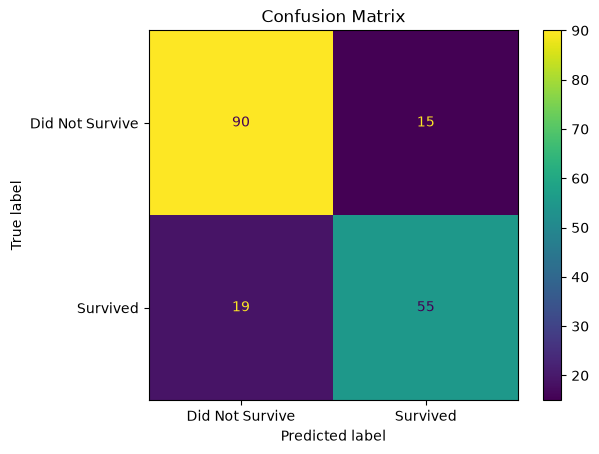

In [15]:
# TODO:

y_pred = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Did Not Survive', 'Survived']).plot()
plt.title('Confusion Matrix')
plt.show()

The model makes more false positives if the false positive value is larger. This means it more often predicts that a passenger survived when they actually did not.

### 9. Classification report

> Print a classification report (precision, recall, f1-score) for the test set.

In [16]:
# TODO:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# Interpretation & Predictions

### 10. Pull out your feature names and coefficients

> Your `ColumnTransformer` renames and reorders your columns when it transforms `X`, the numeric columns keep their original names, but the one-hot encoded categorical columns get new names like `Sex_male`. Before you can interpret any coefficient, you need to know which coefficient belongs to which feature.
>
> 1. Get the one-hot encoded feature names out of your fitted `ColumnTransformer` using:
>
>    `.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)`.
> 
> 2. Combine these with your numeric column names, **in the same order your `ColumnTransformer` outputs them** (e.g. numeric columns first, then categorical).
> 
> 3. Pair these feature names with your fitted model's `.coef_[0]` values in a `pandas.Series` (feature names as the index), so you can look up any coefficient by name.

In [22]:
# TODO:
ohe_feature_names = (
    pipeline.named_steps['preprocessing']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_columns)
)

sum_feature_names = numeric_columns + list(ohe_feature_names)
coeffs = pipeline.named_steps['model'].coef_[0]
coefficient_series = pd.Series(coeffs,index=sum_feature_names)

print(coefficient_series)

Pclass       -0.777620
Age          -0.393647
SibSp        -0.343765
Parch        -0.085486
Fare          0.128723
Sex_male     -2.592776
Embarked_Q   -0.111205
Embarked_S   -0.401304
dtype: float64


### 11. Interpret one coefficient

> Pick one feature and interpret its coefficient. Convert it from log-odds into an odds ratio (`np.exp(coef)`), and explain in a sentence what it does to the odds of survival.

In [26]:
# TODO:
feature_name = 'Fare'
log_odds = coefficient_series[feature_name]
odds_ratio = np.exp(log_odds)

print(f"Log-odds for {feature_name}: {log_odds:.2f}")
print(f"Odds Ratio for {feature_name}: {odds_ratio:.2f}")

Log-odds for Fare: 0.13
Odds Ratio for Fare: 1.14


For every unit increase in the standardized Fare, the odds of survival are multiplied by the odds ratio. Since it is greater than 1, a higher fare increases the odds of survival.

### 12. Generate predictions and predicted probabilities

> Use your model to generate `.predict()` and `.predict_proba()` on the test set. Pick one test observation and explain, in a sentence, what its predicted probability means.

In [28]:
# TODO:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

index = 0
probability = y_prob[index, 1]

print(f"Probability of the survival: {probability:.2f}")

Probability of the survival: 0.11


The model indicates a chance of 11% of surviving, Since it is below 0.50, the passenger is predicted not to survive.

### 12. Try a different threshold

> `.predict()` uses a default threshold of 0.5 on `.predict_proba()` to decide the class. Try lowering it and recompute the confusion matrix and classification report at this new threshold. What trade-off do you see between precision and recall?

In [33]:
# TODO:

threshold = 0.25

y_pred_new = (y_prob[:, 1] >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[71 34]
 [ 8 66]]
              precision    recall  f1-score   support

           0       0.90      0.68      0.77       105
           1       0.66      0.89      0.76        74

    accuracy                           0.77       179
   macro avg       0.78      0.78      0.77       179
weighted avg       0.80      0.77      0.77       179



Lowering the threshold wil increase recall because the model predicts more passengers as survived. However, precision may decrease because more non-survivors are incorrectly predicted as survivors.

### 13. Write a function to print classification metrics with explanations

> Write a function `print_classification_metrics(y_true, y_pred)` that calculates **accuracy**, **recall/sensitivity**, **precision**, **specificity**, and **F1 score**, and prints each metric alongside a clear explanation. Then call your function on your model's test set predictions.
>
> Use the confusion matrix layout below as your reference for which cells (`TP`, `TN`, `FP`, `FN`) each metric is built from.

**Accuracy** — Overall, how often is the classifier correct?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Accuracy} = \frac{TP + TN}{Total}$$

**Recall / Sensitivity / True Positive Rate (TPR)** — Among all passengers who actually survived, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Recall} = \frac{TP}{TP + FN}$$

**Precision** — Among all passengers predicted to survive, what proportion actually did?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Precision} = \frac{TP}{TP + FP}$$

**Specificity / True Negative Rate (TNR)** — Among all passengers who did not actually survive, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center">TP</td>
</tr>
</table>

$$\textbf{Specificity} = \frac{TN}{TN + FP}$$

**$F_1$ score** — The balance between precision and recall.

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


In [45]:
# TODO:
def print_classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    specificity = tn / (tn + fp)
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"Accuracy: {accuracy:.3f}")
    print("Overall, how often the model is correct.\n")

    print(f"Recall: {recall:.3f}")
    print("How many actual survivors were correctly identified.\n")

    print(f"Precision: {precision:.3f}")
    print("How many predicted survivors actually survived.\n")

    print(f"Specificity: {specificity:.3f}")
    print("How many non-survivors were correctly identified.\n")

    print(f"F1 Score: {f1:.3f}")
    print("Balance between precision and recall.")

print_classification_metrics(y_test, y_pred)

Accuracy: 0.810
Overall, how often the model is correct.

Recall: 0.743
How many actual survivors were correctly identified.

Precision: 0.786
How many predicted survivors actually survived.

Specificity: 0.857
How many non-survivors were correctly identified.

F1 Score: 0.764
Balance between precision and recall.
